# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs
Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus

In [ ]:
!nvidia-smi

Sun Apr 13 16:28:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


### **Setting up YOLOSeg11 & Ultralytics**

In [ ]:
%%capture
%pip install "ultralytics<=8.3.40" supervision roboflow

In [ ]:
import ultralytics
ultralytics.checks()
from ultralytics import YOLO
from PIL import Image

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.3/112.6 GB disk)


### **Loading Roboflow Dataset**

In [21]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from roboflow import Roboflow

rf = Roboflow(api_key="XaYRaTIxrFcAN0CfHjEN")

workspace = rf.workspace("ahmed-ws")
project = workspace.project("pannuke-gan-augmented")
version = project.version(3)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PanNuke-GAN-Augmented-3 in yolov11:: 100%|██████████| 6146/6146 [00:00<00:00, 8601.93it/s]


### **Traing YOLOSeg on Custom Data**

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s-seg.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

In [23]:
!ls {HOME}/runs/segment/train/

args.yaml					    MaskR_curve.png
BoxF1_curve.png					    results.csv
BoxP_curve.png					    results.png
BoxPR_curve.png					    train_batch0.jpg
BoxR_curve.png					    train_batch1.jpg
confusion_matrix_normalized.png			    train_batch2.jpg
confusion_matrix.png				    val_batch0_labels.jpg
events.out.tfevents.1744562599.e64a52698a50.5477.0  val_batch0_pred.jpg
labels_correlogram.jpg				    val_batch1_labels.jpg
labels.jpg					    val_batch1_pred.jpg
MaskF1_curve.png				    val_batch2_labels.jpg
MaskP_curve.png					    val_batch2_pred.jpg
MaskPR_curve.png				    weights


### **Confusion Matrix**

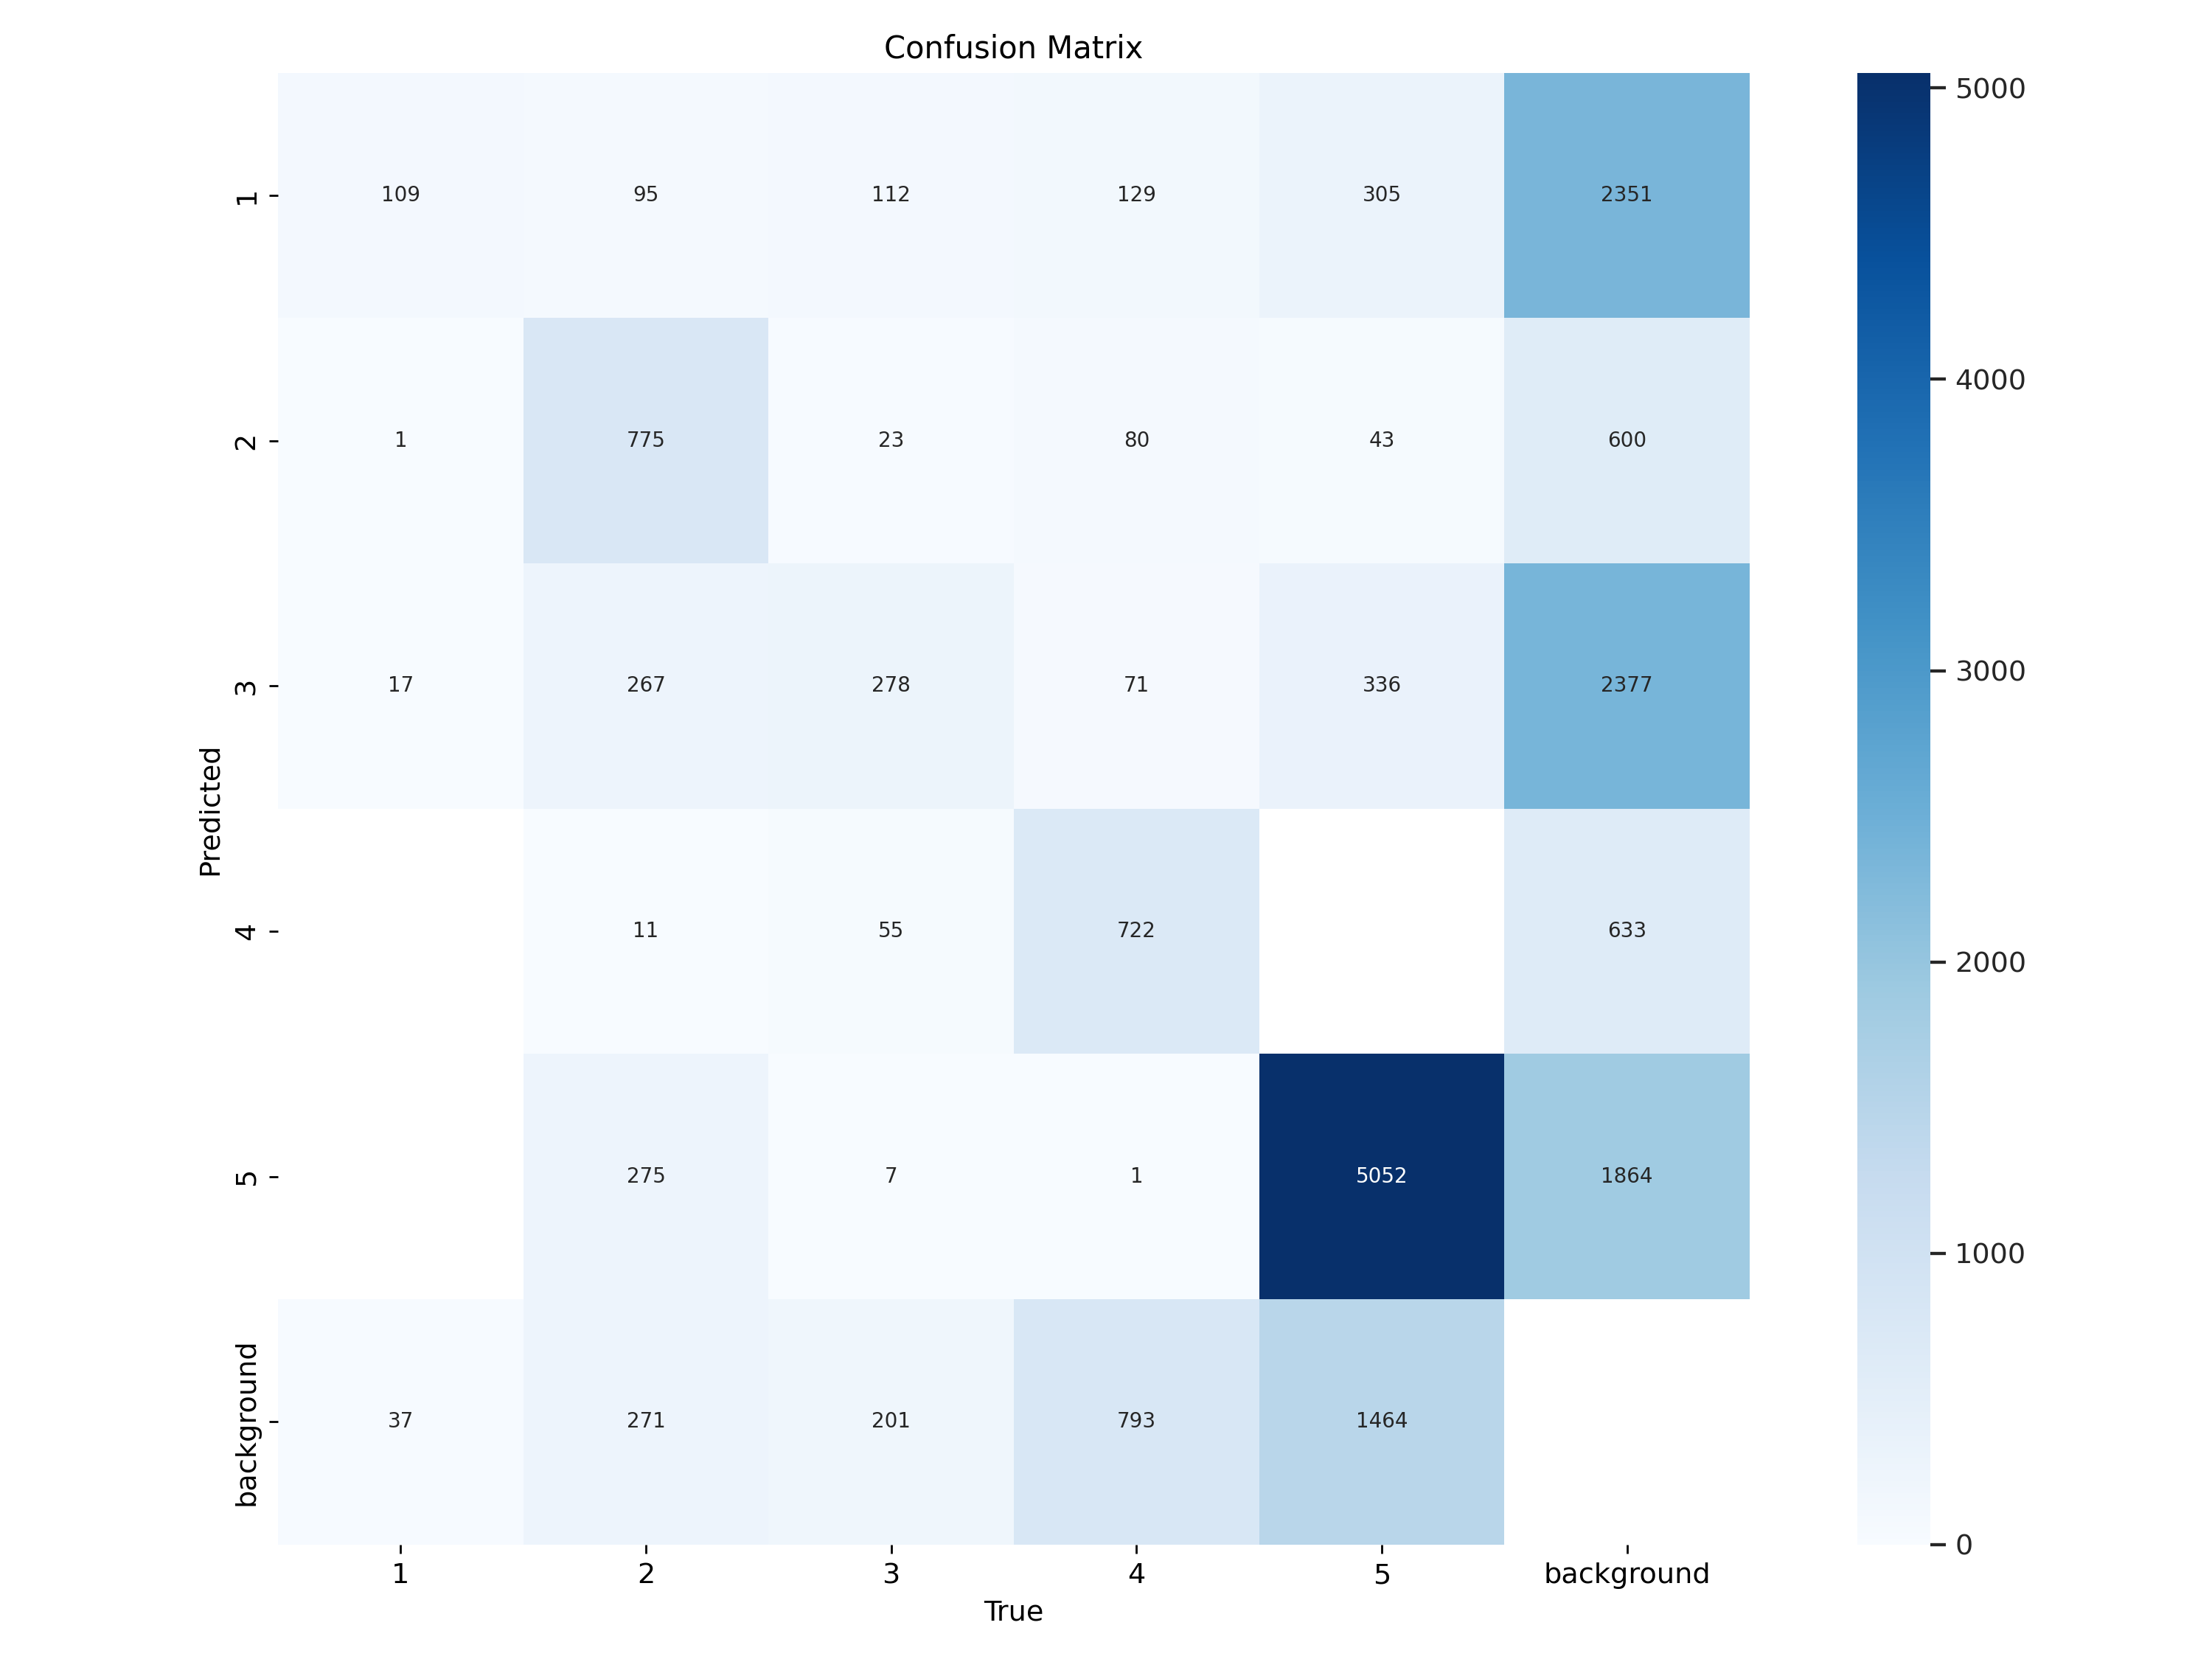

In [24]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/train/confusion_matrix.png', width=600)

### **Training Graphs**

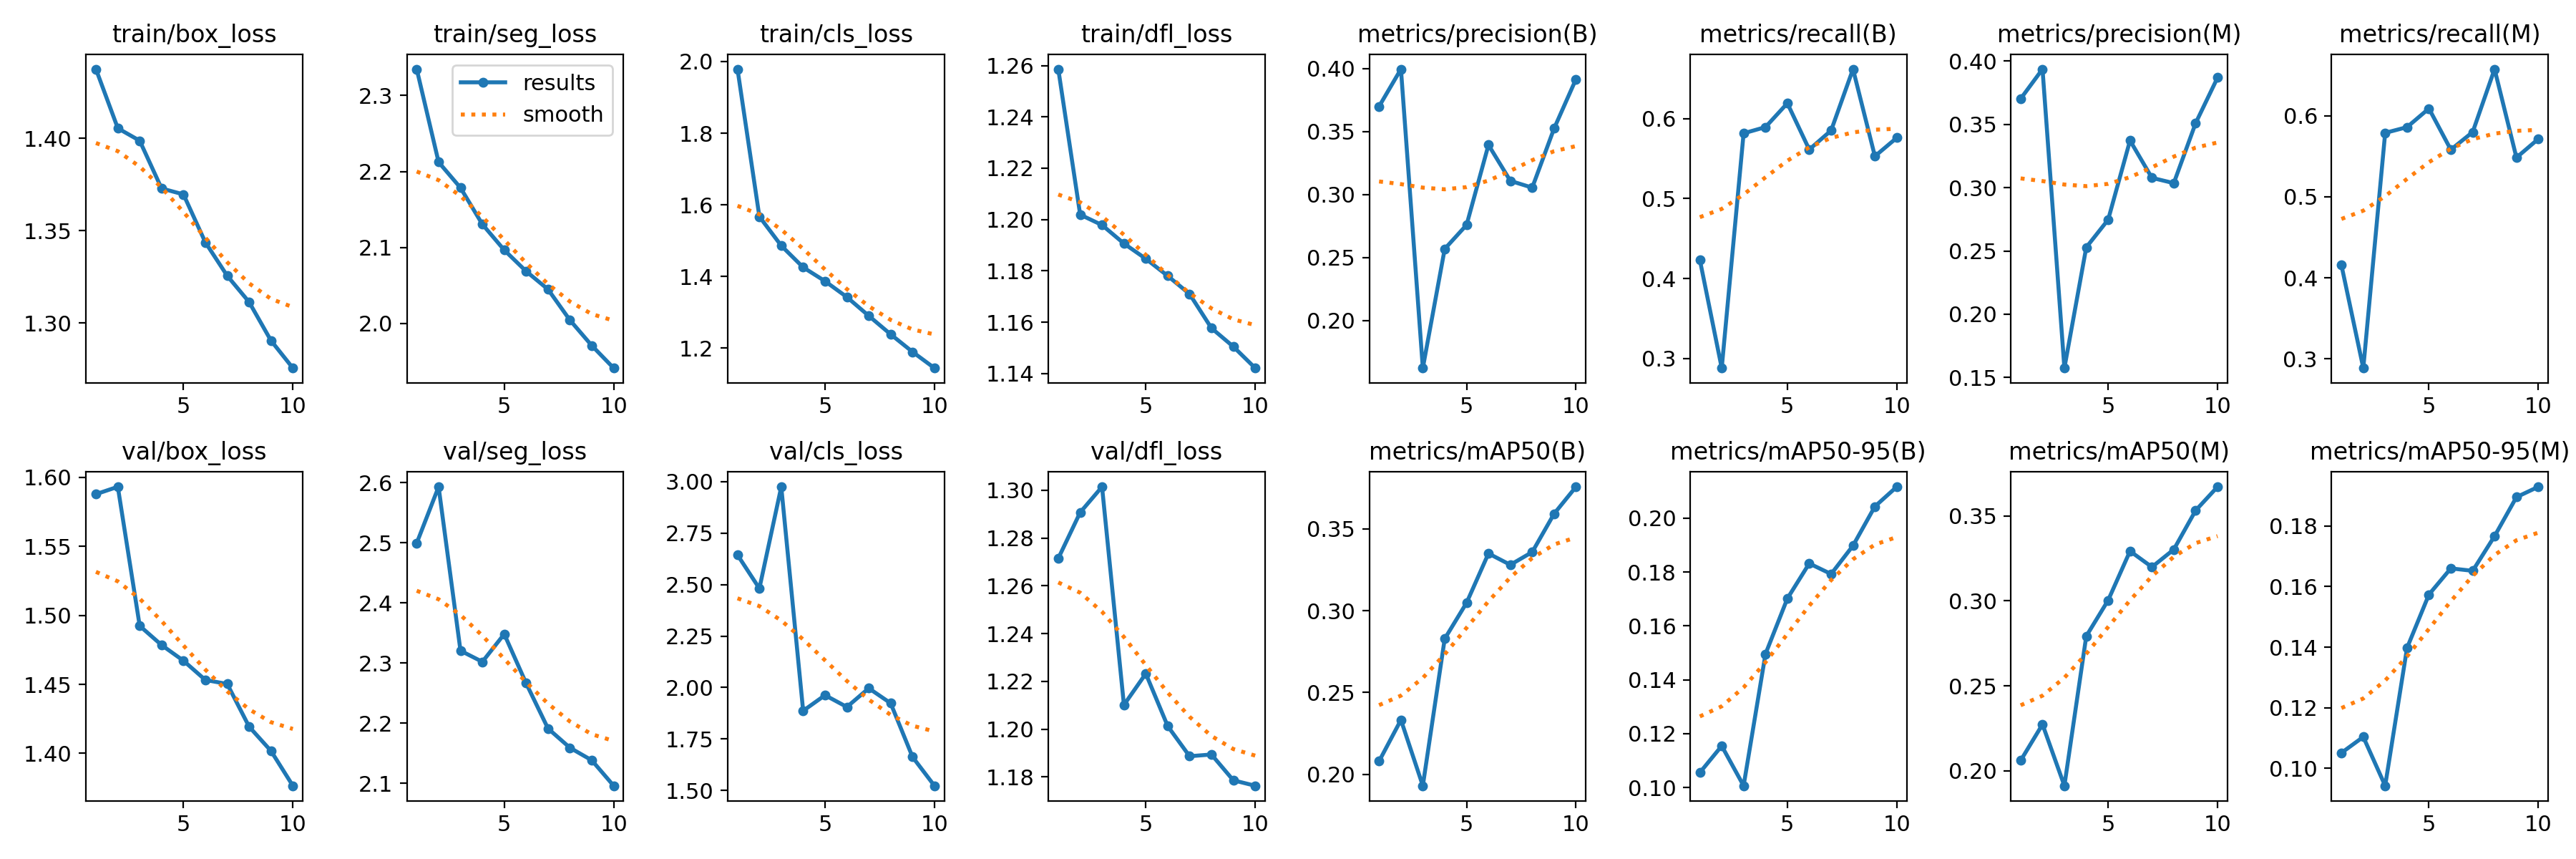

In [ ]:
IPyImage(filename=f'{HOME}/runs/segment/train/results.png', width=600)

### **Validation Predictions**

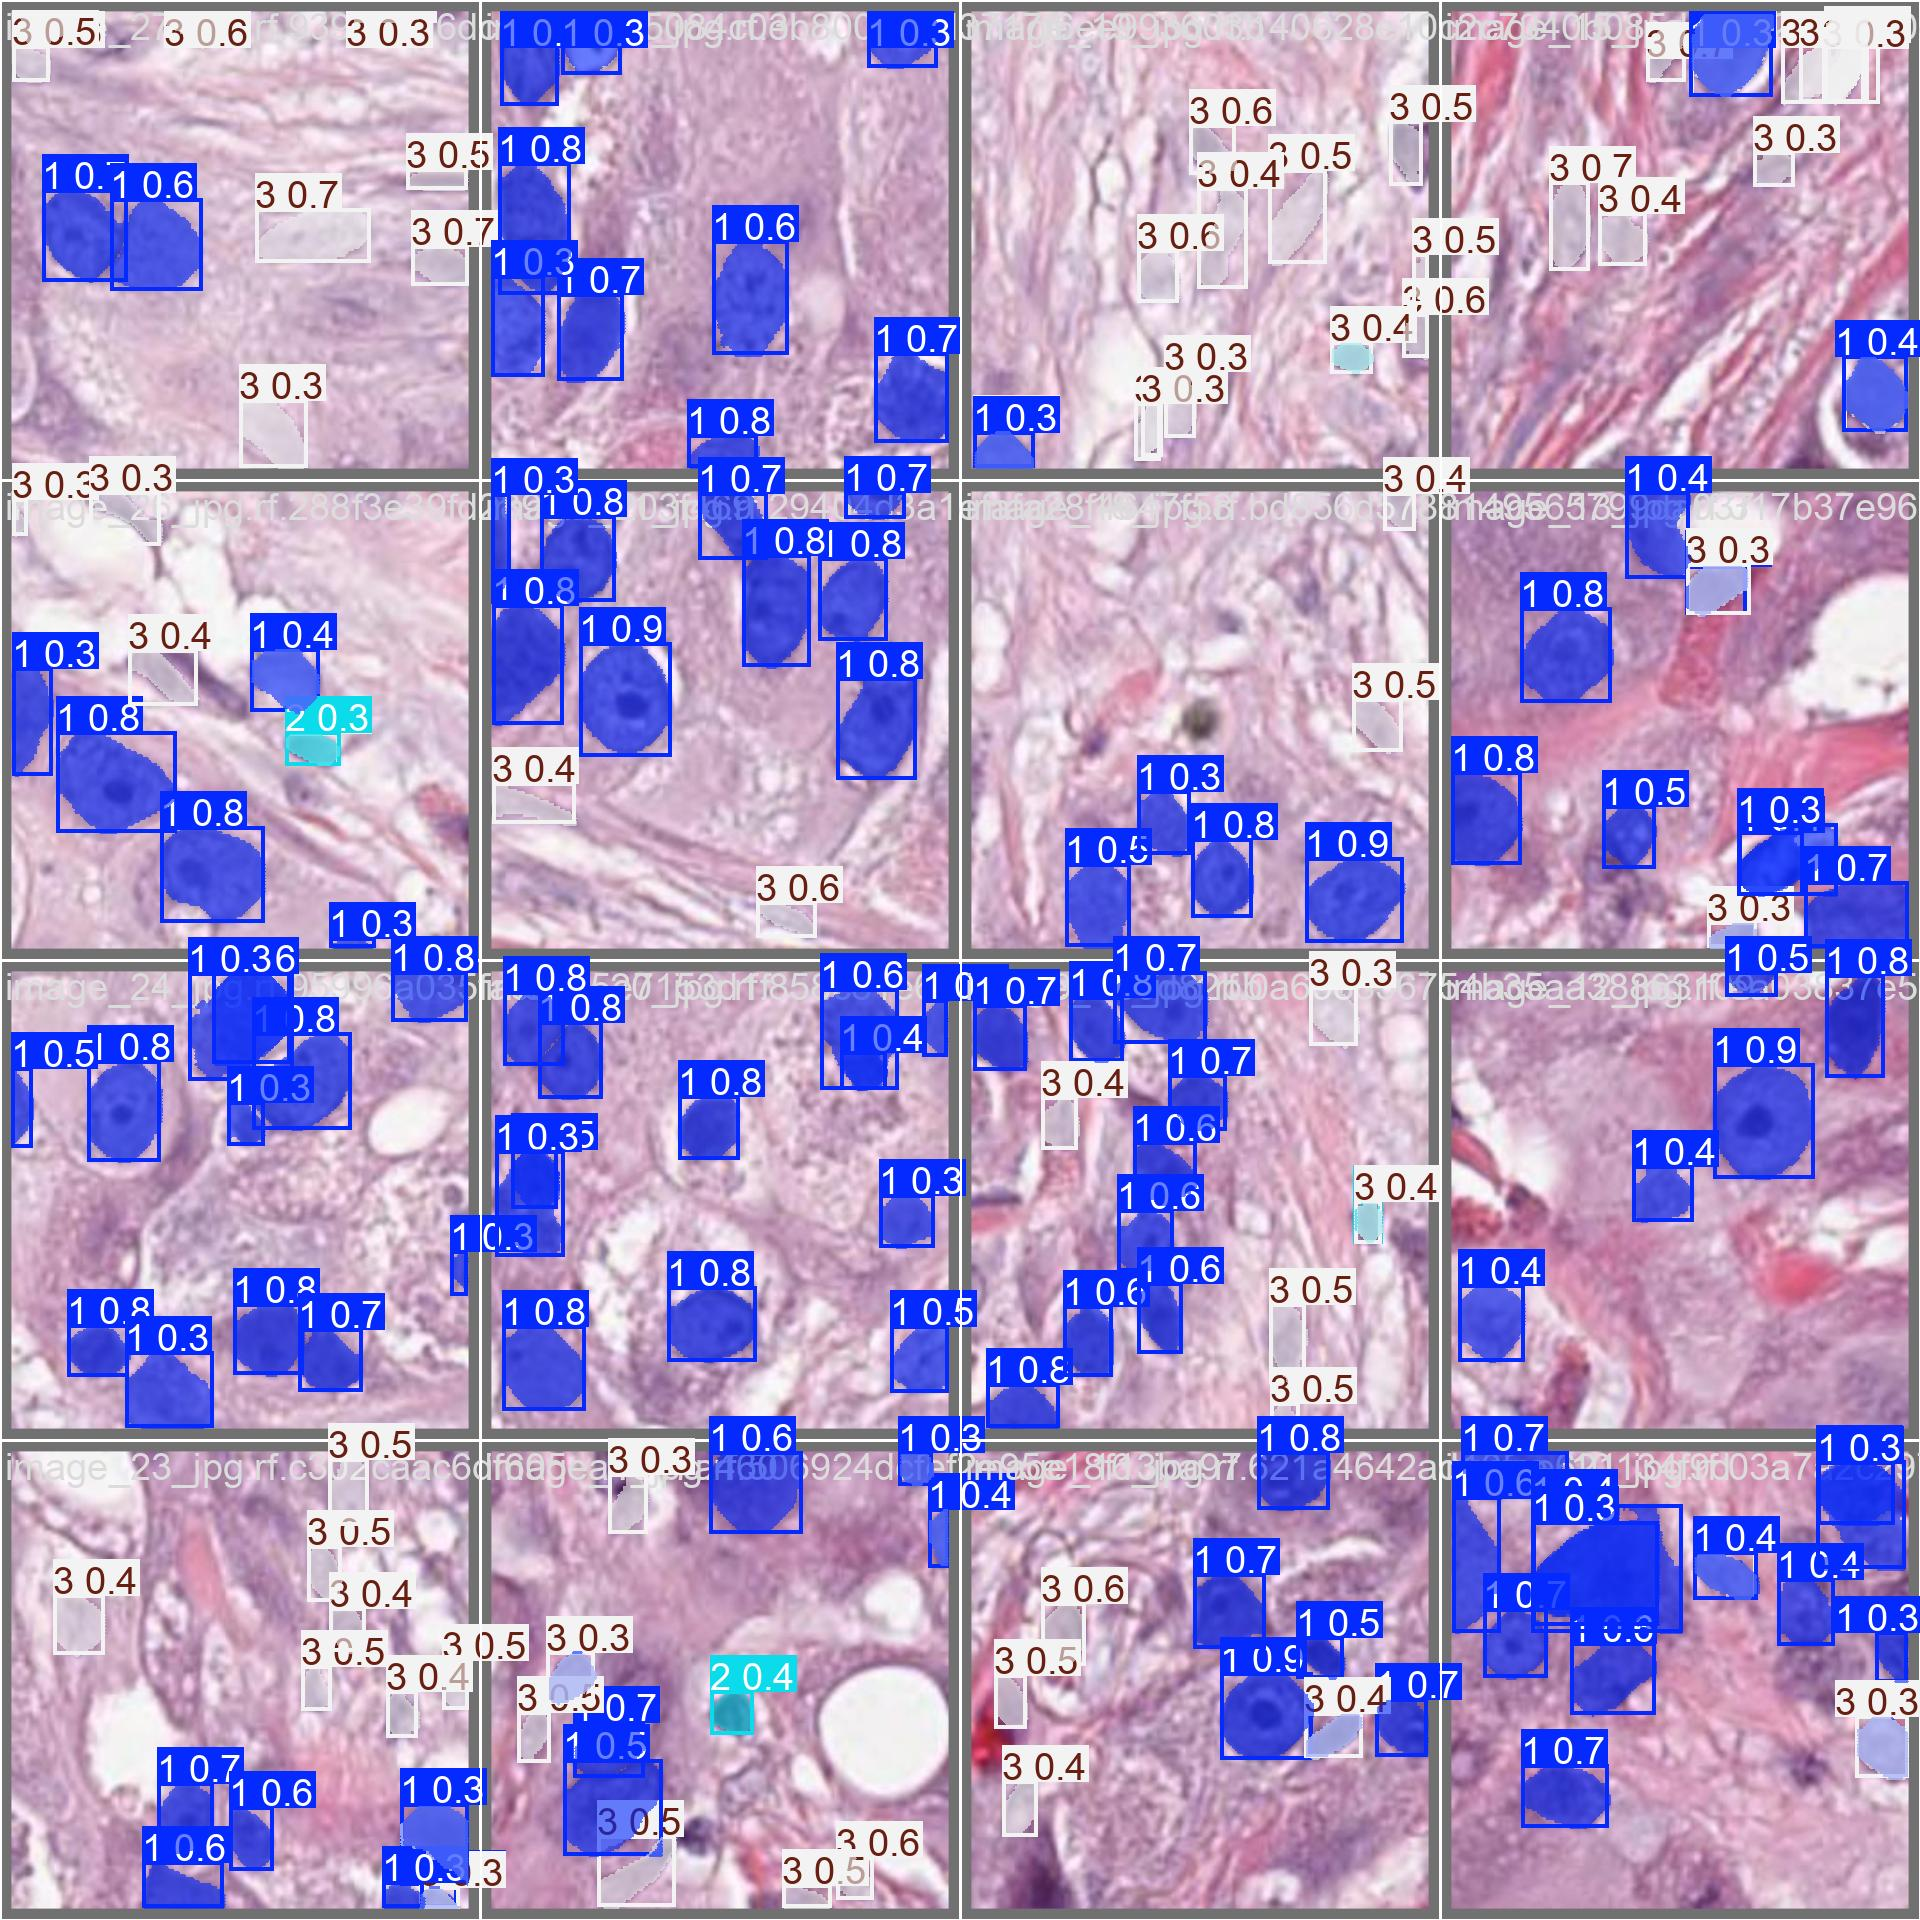

In [ ]:
IPyImage(filename=f'{HOME}/runs/segment/train/val_batch0_pred.jpg', width=600)

### **Shifting model for further use**

In [43]:
!cp -r {HOME}/runs/segment/train/weights/best.pt /content

### **Inference Time**

In [44]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('best.pt')
image = Image.open("/content/Screenshot 2025-04-13 at 10.03.20 PM.png")
result = model.predict(image, conf=0.25)[0]


0: 640x640 39 1s, 3 2s, 20.2ms
Speed: 3.7ms preprocess, 20.2ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)


In [45]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

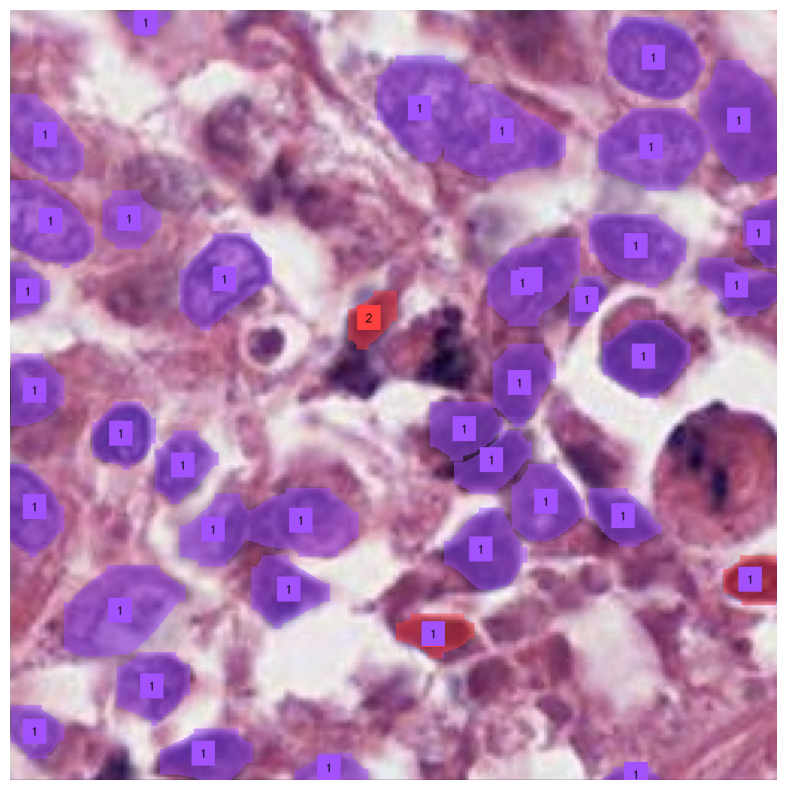

In [46]:
mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK, text_position=sv.Position.CENTER)

annotated_image = image.copy()
annotated_image = mask_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))